Here we are going to generate a brain image concert where each pian note will change a roi in the brain

In [ ]:
### install dependencies
# !pip install pydub
# !pip install moviepy


In [60]:
import os
import subprocess

# imports
import sys

import ipynbname  # needed for notebook_path = ipynbname.path() to work
import numpy as np

PROJECT_ROOT = ipynbname.path().parent.parent.parent
sys.path.append(str(PROJECT_ROOT))


from itertools import product

import concert_utils.image_utils as cu_image_utils
import concert_utils.sound_utils as cu_sound_utils

# Image Stuff --------------------
from moviepy import AudioFileClip, ImageClip, concatenate_videoclips

# Sound Stuff --------------------
from pydub import AudioSegment

import configs as cfg
import src.utils.functions as fc
import src.utils.nifti_functions as nfc
import src.utils.util_freesurfer_segmentation as ufs
import src.utils.utils_io as uio
from src.utils import data_normalization, prep_segmentation

# configs
PATH_BASE = ipynbname.path().parent
PATH_DATA = os.path.join(PATH_BASE, "data")
PATH_TEMP = os.path.join(PATH_DATA, "__temp__")
PATH_INPUT = os.path.join(PATH_DATA, "inputs")
PATH_OUTPUT = os.path.join(PATH_DATA, "outputs")
PATH_OUTPUT_BASE_IMAGES = os.path.join(PATH_OUTPUT, "base_images")
PATH_OUTPUT_NOTE_IMAGES = os.path.join(PATH_OUTPUT, "note_images")
PATH_OUTPUT_CONCERT_VIDEOS = os.path.join(PATH_OUTPUT, "concert_videos")

os.makedirs(PATH_OUTPUT_BASE_IMAGES, exist_ok=True)
os.makedirs(PATH_OUTPUT_NOTE_IMAGES, exist_ok=True)
os.makedirs(PATH_OUTPUT_CONCERT_VIDEOS, exist_ok=True)
SEED = 2
BRAINST_IMG_DIFUSION_STEPS = 50

BPS = 2 # beats per second (bigger is faster)
FPS = 24

USED_AXIAL_LAYER = cfg.SHAPE_PREP_IMG[2]//2
USED_CORONAL_LAYER = cfg.SHAPE_PREP_IMG[1]//2
USED_SAGITTAL_LAYER = cfg.SHAPE_PREP_IMG[0]//2 -15


# Base image generation (Synthesis)

First let's generate the initial image representing silence (any note is being played)

Reading target roi volumes from: target_vol_standardized.json
Target roi volumes: {'total_vol': 0.0, 'surrounding_csf_vol': 0.0, 'cortical_gm_vol': 0.0, 'cerebral_wm_vol': 0.0, 'lateral_ventricles_vol': 0.0, 'third_ventricle_vol': 0.0, 'fourth_ventricle_vol': 0.0, 'thalamus_vol': 0.0, 'hippocampus_vol': 0.0, 'amygdala_vol': 0.0, 'putamen_vol': 0.0, 'pallidum_vol': 0.0, 'caudate_vol': 0.0, 'accumbens_area_vol': 0.0, 'ventral_dc_vol': 0.0, 'cerebellum_gm_vol': 0.0, 'cerebellum_wm_vol': 0.0, 'brainstem_vol': 0.0}


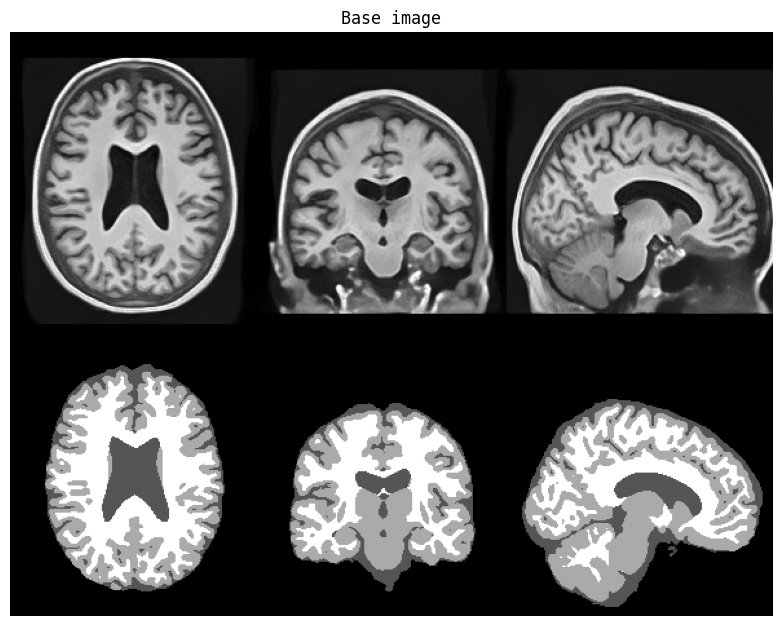

In [61]:
# read the set of null roi volumns
path_target_null_roi_volumes = os.path.join(PATH_INPUT, "target_vol_standardized.json")
target_null_roi_volumes_dict = uio.load_json(path_target_null_roi_volumes)
print(f"Reading target roi volumes from: {os.path.basename(path_target_null_roi_volumes)}")
print(f"Target roi volumes: {target_null_roi_volumes_dict}")

# generate the base image
path_name_base_img = os.path.join(PATH_OUTPUT_BASE_IMAGES, "base0.nii.gz")
if not os.path.exists(path_name_base_img):
    print(f"Generating base image: {path_name_base_img}")
    command = ["python", 
                os.path.join(PROJECT_ROOT, "main_generation.py"), 
                "--generation_type", "synthesis", 
                "--path_target_roi_volumes", path_target_null_roi_volumes,
                "--output_dir", os.path.dirname(path_name_base_img),
                "--output_name", os.path.basename(path_name_base_img),
                "--seed", str(SEED),
                "--diffusion_steps", str(BRAINST_IMG_DIFUSION_STEPS),
                "--target_roi_volumes_scale", "standardized"
                ]

    result = subprocess.run(command, capture_output=True, text=True)
    if result.returncode != 0:
        print("Error:", result.stderr)

# segment the base image
path_name_base_seg = os.path.join(PATH_OUTPUT_BASE_IMAGES, "base0_seg.nii.gz")
prep_segmentation.save_synthseg_segmentation(path_name_base_img, path_name_base_seg, verify=True)


# show the base image
if os.path.exists(path_name_base_img):
    base_img, _ = nfc    .load_nifti(path_name_base_img)
    base_seg, _ = nfc.load_nifti(path_name_base_seg)
    base_seg3 = ufs.merge_seg96_to_seg3(base_seg)

    base_img = data_normalization.normalize_image(base_img)
    base_seg3 = data_normalization.normalize_image(base_seg3)
    img_2D_list = fc.cat_3_views([base_img, base_seg3], axis=1, layer_offset=[0, 0, 10], img_cropping=50)

    fc.imgshow_list(img_2D_list, name="Base image", custom_disposition=(2,None))
else:
    raise FileNotFoundError(f"Base image not found: {path_name_base_img}")

# Note images generation (Transformation)

In [62]:

# create notes and combinations of notes
all_structure_code = ["a","b", "c", "d", "e", "f", "g", "h", "i", "j", "k", "l", "m", "n", "o", "p", "q", "r"] # one letter per possible structure
possible_volume_changes = [3,-3] # indicates note up or down
used_structure_code = ["a", "b", "c", "d", "e", "h", "i", "p", "q", "r"] # reduced list of structures (most visible ones)

combinations_list = []
combinations_list.extend([c for c in used_structure_code ]) # single note
# combinations_list.extend([''.join(c) for c in combinations(used_structure_code, 2)]) # two notes
# combinations_list.extend([''.join(c) for c in combinations(used_structure_code, 3)]) # three notes

structures =  list(target_null_roi_volumes_dict.keys())

# create images based on the notes
print("------------ Structure combinations:", len(combinations_list))
for combo in combinations_list:
    print("Creating ", combo)
    _st_code_list = [_c for _c in combo]
    _st_idx_list = [all_structure_code.index(_c) for _c in _st_code_list]
    # print(_st_idx_list)
    

    product_values = list(product(possible_volume_changes, repeat=len(_st_idx_list)))
    print(product_values)
    for val_tuple in product_values:
        _target_roi_volumes_dict = target_null_roi_volumes_dict.copy()
        for i, st_idx in enumerate(_st_idx_list):
            st_name = structures[st_idx]
            _target_roi_volumes_dict[st_name] = val_tuple[i]
            # print(st_name)

        output_name = "_".join([f"{v}{c}" for v, c in zip(val_tuple, _st_code_list)]) + ".nii.gz"
        _path_name_output_img = os.path.join(PATH_OUTPUT_NOTE_IMAGES, output_name)
        
        if not os.path.exists(_path_name_output_img):
            _path_name_output_target_roi_volumes_dict = os.path.join(PATH_TEMP, output_name.replace(".nii.gz", ".json"))
            print("Output name:", output_name)
            print(_target_roi_volumes_dict)
            uio.save_json(_target_roi_volumes_dict, _path_name_output_target_roi_volumes_dict)
            

            print("Transforming base image")
            command = ["python", 
                        os.path.join(PROJECT_ROOT, "main_generation.py"), 
                        "--generation_type", "transformation", 
                        "--path_image", path_name_base_img,
                        "--path_segmentation", path_name_base_seg,
                        "--path_target_roi_volumes", _path_name_output_target_roi_volumes_dict,
                        "--output_dir", os.path.dirname(_path_name_output_img),
                        f"--output_name={os.path.basename(_path_name_output_img)}",
                        "--seed", str(SEED),
                        "--diffusion_steps", str(BRAINST_IMG_DIFUSION_STEPS),
                        "--target_roi_volumes_scale", "standardized"
                        ]
            # print("Running command:", " ".join(command))
            result = subprocess.run(command, capture_output=True, text=True)
            if result.returncode != 0:
                print("Error:", result.stderr)
        else:
            print(f"Output image already exists: {output_name}")
    #     break
    # break

------------ Structure combinations: 10
Creating  a
[(3,), (-3,)]
Output image already exists: 3a.nii.gz
Output image already exists: -3a.nii.gz
Creating  b
[(3,), (-3,)]
Output image already exists: 3b.nii.gz
Output image already exists: -3b.nii.gz
Creating  c
[(3,), (-3,)]
Output image already exists: 3c.nii.gz
Output image already exists: -3c.nii.gz
Creating  d
[(3,), (-3,)]
Output image already exists: 3d.nii.gz
Output image already exists: -3d.nii.gz
Creating  e
[(3,), (-3,)]
Output image already exists: 3e.nii.gz
Output image already exists: -3e.nii.gz
Creating  h
[(3,), (-3,)]
Output image already exists: 3h.nii.gz
Output image already exists: -3h.nii.gz
Creating  i
[(3,), (-3,)]
Output image already exists: 3i.nii.gz
Output image already exists: -3i.nii.gz
Creating  p
[(3,), (-3,)]
Output image already exists: 3p.nii.gz
Output image already exists: -3p.nii.gz
Creating  q
[(3,), (-3,)]
Output image already exists: 3q.nii.gz
Output image already exists: -3q.nii.gz
Creating  r
[(3

# Sound Generation (only)

In [63]:
# Notes (pulses)
N4 = 4 #(whole note)
N2 = 2 #(half note)
N1_5 = 1.5 #(dotted quarter note)
N1 = 1 #(quarter note)
N0_5 = 0.5 #(beat)
N0_25 = 0.25 #(sixteenth note)

# Notes names
C = "C" # do
D = "D" # re
E = "E" # mi
F = "F" # fa
G = "G" # sol
A = "A" # la
B = "B" # si

NOTE_STRUCTURE_MAPPING = {
    C: "c", # cortical_gm 
    D: "d", # cerebral_wm
    E: "e", # lateral_ventricles
    F: "h", # thalamus
    G: "p", # cerebellum_gm
    A: "b", # surrounding_csf
    B: "a"  # total
}

STRUCTURE_NOTE_MAPPING = {v.upper(): k for k, v in NOTE_STRUCTURE_MAPPING.items()}

# note tests
note_test_sound = {
    "melody_name": "note_test",
    "scale_left": ("C", "major", 3),
    "scale_right": ("C", "major", 4),
    "melody": [
        (None, N4),
        # Intro
        (C, N4), (C, N4), (None, N2), (D, N4), (D, N4), (None, N2),
        (E, N4), (E, N4), (None, N2), (F, N4), (F, N4), (None, N2),
        (G, N4), (G, N4), (None, N2), (A, N4), (A, N4), (None, N2),
        (B, N4), (B, N4), (None, N2), (C, N4), (C, N4), (None, N2),

        (C, N4), (D, N4), (E, N4), (F, N4),
        (G, N4), (A, N4), (B, N4), (C, N4)
    ] #* 2  # Repeat the melody twice
}




# Hymn "Ode to Joy" by Beethoven, in the key of C major
ode_to_joy = {
    "melody_name": "ode_to_joy",
    "scale_left": ("C", "major", 3),
    "scale_right": ("C", "major", 4),
    "melody": [

    (None, N4),

    # Phrase 1
    (E, N1), (E, N1), (F, N1), (G, N1),
    (G, N1), (F, N1), (E, N1), (D, N1),
    (C, N1), (C, N1), (D, N1), (E, N1),
    (E, N1_5), (D, N0_5), (D, N2),

    # Phrase 2
    (E, N1), (E, N1), (F, N1), (G, N1),
    (G, N1), (F, N1), (E, N1), (D, N1),
    (C, N1), (C, N1), (D, N1), (E, N1),
    (D, N1_5), (C, N0_5), (C, N2),

    # # Phrase 3
    # (D, N1), (D, N1), (E, N1), (C, N1),
    # (D, N1), (E, N0_5), (F, N0_5), (E, N1), (C, N1),
    # (D, N1), (G, N1), (E, N1), (C, N1),
    # (D, N1), (G, N1), (E, N1), (D, N1),

    # Phrase 3
    (D, N1), (D, N1), (E, N1), (C, N1),
    (D, N1), (E, N0_5), (F, N0_5), (E, N1), (C, N1),
    (D, N1), (E, N0_5), (F, N0_5), (E, N1), (D, N1),
    (C, N1), (D, N1), (G, N2),

    # Phrase 4
    (E, N1), (E, N1), (F, N1), (G, N1),
    (G, N1), (F, N1), (E, N1), (D, N1),
    (C, N1), (C, N1), (D, N1), (E, N1),
    (D, N1_5), (C, N0_5), (C, N2),

    ]  # Repeat the melody twice
}


fur_elise = {
    "melody_name": "fur_elise",
    "scale_left": ("A", "minor", 3),
    "scale_right": ("A", "minor", 4),
    "melody": [
            (None, N4),

            (E, N0_5), (D, N0_5), (E, N0_5), (D, N0_5), (E, N0_5),
            (B, N0_5), (D, N0_5), (C, N0_5), (A, N1),

            (C, N0_5), (E, N0_5), (A, N0_5), (B, N1),
            (E, N0_5), (G, N0_5), (B, N0_5), (C, N1),

            (E, N0_5), (D, N0_5), (E, N0_5), (D, N0_5), (E, N0_5),
            (B, N0_5), (D, N0_5), (C, N0_5), (A, N1),

            (C, N0_5), (E, N0_5), (A, N0_5), (B, N1),
            (E, N0_5), (C, N0_5), (B, N0_5), (A, N2),
            
            # Next phrase
            (E, N0_5), (A, N0_5), (B, N0_5), (C, N1),
            (E, N0_5), (C, N0_5), (B, N0_5), (A, N1),

            (B, N0_5), (C, N0_5), (D, N0_5), (E, N1),
            (G, N0_5), (F, N0_5), (E, N0_5), (D, N1),

            (C, N0_5), (E, N0_5), (D, N0_5), (C, N1),
            (B, N0_5), (D, N0_5), (C, N0_5), (A, N1),

            # Transition back toward theme
            (A, N0_5), (C, N0_5), (E, N0_5), (A, N1),
            (G, N0_5), (F, N0_5), (E, N0_5), (D, N1),

            (C, N0_5), (E, N0_5), (A, N0_5), (B, N1),
            (E, N0_5), (C, N0_5), (B, N0_5), (A, N2)
        ]
}



### ----- Example how to generate the music
# sound_description = note_test_sound
sound_description = fur_elise
# sound_description = ode_to_joy

sound_right = AudioSegment.silent(duration=0)
sound_left = AudioSegment.silent(duration=0)
note_freq_right = cu_sound_utils.get_scale(sound_description["scale_right"][0], sound_description["scale_right"][1], sound_description["scale_right"][2])
note_freq_left = cu_sound_utils.get_scale(sound_description["scale_left"][0], sound_description["scale_left"][1], sound_description["scale_left"][2])

for note, beats in sound_description["melody"]:
    duration = beats / BPS
    duration_ms = int(duration * 1000)

    if note is not None:
        freq_right = note_freq_right[note]
        freq_left = note_freq_left[note]

        sound_right += cu_sound_utils.generate_piano_note(freq_right, duration)
        sound_left += cu_sound_utils.generate_piano_note(freq_left, duration)
    else:
        # Rest
        silence = AudioSegment.silent(duration=duration_ms)
        sound_right += silence
        sound_left += silence


full_sound = sound_right.overlay(sound_left-6)
music_path_name = os.path.join(PATH_OUTPUT_CONCERT_VIDEOS, f"only_sound_{sound_description['melody_name']}.wav")
full_sound.export(music_path_name, format="wav")
print(f"Exported sound to: {os.path.basename(music_path_name)}")

Exported sound to: only_sound_fur_elise.wav


# Video generation (only)

### Piano video

In [ ]:
# obtain the brain images for each note
NOTE_STRUCTURE_INDEX_MAPPING = {}
NOTE_STRUCTURE_NAME_MAPPING = {}
for note, _structure_code in NOTE_STRUCTURE_MAPPING.items():
    NOTE_STRUCTURE_NAME_MAPPING[note] = cfg.STRUCTURE_NAME_LIST[all_structure_code.index(_structure_code)]
    NOTE_STRUCTURE_INDEX_MAPPING[note] = cfg.STRUCTURE_INDEX_LIST[all_structure_code.index(_structure_code)]


default_piano_brain_img_list = [[], [], []] # 0: default, 1: up, 2: down
active_piano_brain_img_list = [[], [], []] # 0: default, 1: up, 2: down
bg_color = (255, 255, 255)
brain_color = (128, 128, 128)

highlighted_colors = {
    "default": (200, 200, 200),
    "3": (94, 253, 237),
    "-3": (250, 143, 143),

}

def find_best_axial_layer(segmentation, structure_index):
    # Find the best axial layer for the given structure index
    structure_mask = ufs.merge_seg96_to_mask(segmentation, structure_index)  # Get the binary mask for the structure
    axial_sums = np.sum(structure_mask, axis=(0, 1))  # Sum over x and y axes
    best_layer = np.argmax(axial_sums)  # Get the index of the layer with the maximum sum
    return best_layer


for note in cu_image_utils.WHITE_KEYS: 
    _seg2D_base = base_seg[...,USED_AXIAL_LAYER]
    if NOTE_STRUCTURE_MAPPING[note] not in ('a', 'b', 'c', 'd', 'e'): # total, gm, wm, ventricles, csf
        _seg2D_base = base_seg[USED_SAGITTAL_LAYER]

    # best_layer = find_best_axial_layer(base_seg, NOTE_STRUCTURE_INDEX_MAPPING.get(note))
    # _seg2D_base = base_seg[..., best_layer]
    for i, (_state, highlighted_color) in enumerate(highlighted_colors.items()):
        _seg2D = cu_image_utils.get_highlighted_structure(_seg2D_base, 
                                                            NOTE_STRUCTURE_INDEX_MAPPING.get(note), 
                                                            bg_color=bg_color, 
                                                            brain_color=brain_color, 
                                                            highlighted_color=highlighted_color)
        _seg2D = np.transpose(_seg2D, (1, 0, 2)) # transpose to match the orientation of the piano keys
        _seg2D = np.flipud(_seg2D)
        if i == 0:
            default_piano_brain_img_list[i].append(_seg2D)
        else:
            active_piano_brain_img_list[i-1].append(_seg2D)


# ----- Create image video

# active_colors=["#B9FEF7", "#5EFDED"]
active_colors=["#B9FEF7", "#FA8F8F"]

frames = []
prev_note = None
repeated_change_index = 0
default_change_index = 0

piano_characteristics = {
    "width": 1400,
    "height": 300,
    "font_size": 32,
    "white_key_text_y": 220,
    "black_key_text_y": 120,
    "white_key_image_y": 310,
    "white_image_height": 130,
    "white_key_image_x_offset": None
}

for note, time in sound_description["melody"]:
    _used_piano_brain_img_list = default_piano_brain_img_list[0].copy()  # default state
    _used_active_color = None
    
    if note is not None:
        _index_note = cu_image_utils.WHITE_KEYS.index(note)

        _used_piano_brain_img_list[_index_note] = active_piano_brain_img_list[default_change_index][_index_note]  # highlight the active note
        _used_active_color = active_colors[default_change_index]

        if prev_note is not None and prev_note == note:
            repeated_change_index += 1
            _used_piano_brain_img_list[_index_note] = active_piano_brain_img_list[repeated_change_index % len(possible_volume_changes)][_index_note]
            _used_active_color = active_colors[repeated_change_index % len(possible_volume_changes)]
        else:
            repeated_change_index = 0
            
    img_piano = cu_image_utils.draw_piano(note, active_color=_used_active_color, **piano_characteristics, white_key_images=_used_piano_brain_img_list)
    
    frames.append((img_piano, time/BPS))

    prev_note = note

piano_height, piano_width = img_piano.shape[:2]


clips = [ImageClip(img).with_duration(d) for img, d in frames]
final_clip = concatenate_videoclips(clips, method="compose")

video_path_name = os.path.join(PATH_OUTPUT_CONCERT_VIDEOS, f"only_video_piano_{sound_description['melody_name']}.mp4")
final_clip.write_videofile(video_path_name, fps=FPS, logger=None)
print(f"Exported video to: {os.path.basename(video_path_name)}")



Exported video to: only_video_piano_fur_elise.mp4


### Brain video

In [56]:
# def get_2D_slice(img_data, layer, to_rgb=True, new_h=None):
#     img_2D = img_data[..., layer]
#     img_2D = img_2D.T
#     img_2D = np.flipud(img_2D)
#     if to_rgb:
#         img_2D = fc.gray_to_rgb(data_normalization.normalize_image(img_2D))
#     if new_h is not None:
#         img_2D = fc.resize_image(img_2D, new_h, mode='h')
#     return img_2D



def get_2D_slice(img_data, to_rgb=True, new_h=None, nb_views=2, axial_layer=USED_AXIAL_LAYER, coronal_layer=USED_CORONAL_LAYER, sagittal_layer=USED_SAGITTAL_LAYER):
    axial_offset = abs(img_data.shape[2]//2 - axial_layer)
    coronal_offset = abs(img_data.shape[1]//2 - coronal_layer)
    sagittal_offset = abs(img_data.shape[0]//2 - sagittal_layer)

    if nb_views == 3:
        img_2D = fc.cat_n_views_different_layers([img_data], axis=1, view_layersoffset_list=((2,axial_offset), (1,coronal_offset), (0,sagittal_offset)), img_cropping=0, to_rgb=to_rgb)[0]
    elif nb_views == 2:
        img_2D = fc.cat_n_views_different_layers([img_data], axis=1, view_layersoffset_list=((2,axial_offset), (0,sagittal_offset)), img_cropping=0, to_rgb=to_rgb)[0]
    else:
        img_2D = fc.cat_n_views_different_layers([img_data], axis=1, view_layersoffset_list=((2,axial_offset)), img_cropping=0, to_rgb=to_rgb)[0]

    if new_h is not None:
        img_2D = fc.resize_image(img_2D, new_h, mode='h')
    return img_2D

# ----- Load images and convert to RGB
used_volume_change = 3 # 3=up, -3=down
images_dict = {}
for st in used_structure_code:
    images_dict[st] = []
    for i, change in enumerate(possible_volume_changes):
        img_data, _ = nfc.load_nifti(os.path.join(PATH_OUTPUT_NOTE_IMAGES, f"{change}{st}.nii.gz"))
        img_2D = get_2D_slice(img_data, to_rgb=True, new_h=512)
        images_dict[st].append(img_2D)

base_img_2D = get_2D_slice(base_img, to_rgb=True, new_h=512)

# ----- Create image video
frames = []
prev_note = None
repeated_change_index = 0

img_height, img_width, _ = images_dict[used_structure_code[0]][0].shape  # get the shape of the first image

for note, time in sound_description["melody"]:
    # images
    if note is not None:
        structure_code = NOTE_STRUCTURE_MAPPING[note]
        img = images_dict[structure_code][default_change_index]
        
        # just to change the image with similar notes
        if prev_note is not None and prev_note == note:
            repeated_change_index += 1
            img = images_dict[structure_code][repeated_change_index % len(possible_volume_changes)]
            # print(repeated_change_index % len(possible_volume_changes))
        else:
            repeated_change_index = 0
    else:
        img = base_img_2D
    frames.append((img, time/BPS))
    prev_note = note


clips = [ImageClip(img).with_duration(d) for img, d in frames]
final_clip = concatenate_videoclips(clips, method="compose")

video_path_name = os.path.join(PATH_OUTPUT_CONCERT_VIDEOS, f"only_video_{sound_description['melody_name']}.mp4")
final_clip.write_videofile(video_path_name, fps=FPS, logger=None)
print(f"Exported video to: {os.path.basename(video_path_name)}")
    

Exported video to: only_video_fur_elise.mp4


# Video with sound

In [57]:
# ---- create music video

frames = []

sound_right = AudioSegment.silent(duration=0)
sound_left = AudioSegment.silent(duration=0)
note_freq_right = cu_sound_utils.get_scale(*sound_description["scale_right"])
note_freq_left = cu_sound_utils.get_scale(*sound_description["scale_left"])


prev_note = None
repeated_change_index = 0

brain_piano_margin = 100
canvas_height = img_height + piano_height + brain_piano_margin
canvas_width = max(img_width, piano_width)
for note, beats in sound_description["melody"]:
    duration = beats / BPS
    duration_ms = int(duration * 1000)

    # ---- image
    _used_piano_brain_img_list = default_piano_brain_img_list[0].copy()  # default state
    _used_active_color = active_colors[default_change_index]

    if note is not None:
        # piano image
        _index_note = cu_image_utils.WHITE_KEYS.index(note)
        _used_piano_brain_img_list[_index_note] = active_piano_brain_img_list[default_change_index][_index_note]  # highlight the active note

        # brain image
        structure_code = NOTE_STRUCTURE_MAPPING[note]
        img_brain = images_dict[structure_code][default_change_index]

        # ---- change if repeated note
        if prev_note is not None and prev_note == note:
            repeated_change_index += 1

            img_brain = images_dict[structure_code][repeated_change_index % len(possible_volume_changes)]

            _used_piano_brain_img_list[_index_note] = active_piano_brain_img_list[repeated_change_index % len(possible_volume_changes)][_index_note]
            _used_active_color = active_colors[repeated_change_index % len(possible_volume_changes)]
        else:
            repeated_change_index = 0
    else:
        img_brain = base_img_2D

    img_piano = cu_image_utils.draw_piano(note, active_color=_used_active_color, **piano_characteristics, white_key_images=_used_piano_brain_img_list)
    
    # create complete image brain centered up, and piano down with separation of 100 pixels
    complete_canvas = np.ones((canvas_height, canvas_width, 3), dtype=np.uint8)
    # center the brain image in x and place it at the top
    brain_x_offset = (canvas_width - img_width) // 2
    complete_canvas[0:img_height, brain_x_offset:brain_x_offset+img_width, :] = img_brain
    # place the piano image at the bottom
    piano_x_offset = (canvas_width - piano_width) // 2
    complete_canvas[img_height+brain_piano_margin:img_height+brain_piano_margin+piano_height, piano_x_offset:piano_x_offset+piano_width, :] = img_piano

    frames.append((complete_canvas, duration))
    prev_note = note
    
    # ---- sound
    if note is not None:
        freq_right = note_freq_right[note]
        freq_left = note_freq_left[note]

        sound_right += cu_sound_utils.generate_piano_note(freq_right, duration)
        sound_left += cu_sound_utils.generate_piano_note(freq_left, duration)
    else:
        # Rest
        silence = AudioSegment.silent(duration=duration_ms)
        sound_right += silence
        sound_left += silence




# ---- Save the sound first
full_sound = sound_right.overlay(sound_left-6)
music_path_name = os.path.join(PATH_OUTPUT_CONCERT_VIDEOS, f"only_sound_{sound_description['melody_name']}.wav")
full_sound.export(music_path_name, format="wav")

# ---- Create the video 
clips = [ImageClip(img).with_duration(d) for img, d in frames]
final_clip = concatenate_videoclips(clips, method="compose")

# ---- import the sound
audio_clip = AudioFileClip(music_path_name)
final_clip = final_clip.with_audio(audio_clip)

# ---- Save the video with sound
video_path_name = os.path.join(PATH_OUTPUT_CONCERT_VIDEOS, f"{sound_description['melody_name']}.mp4")
final_clip.write_videofile(
    video_path_name,
    fps=FPS,
    audio_codec="aac",
    logger=None
)
print(f"Exported video with sound to: {os.path.basename(video_path_name)}")

Exported video with sound to: fur_elise.mp4
